## Number of Deaths by Causes Project

 Number of deaths by causes Dataset

In [1]:
## import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import scipy.stats as stats
import statsmodels.api as sm


In [2]:
## read the death dataset 
death_dataset=pd.read_csv('number_of_deaths.csv')

In [3]:
## make a copy of the original dataset 
death_causes=death_dataset.copy()

In [4]:
## check the dimension of the dataset
death_causes.shape

(8254, 36)

In [5]:
## check the overall info
death_causes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8254 entries, 0 to 8253
Data columns (total 36 columns):
 #   Column                                                                                    Non-Null Count  Dtype  
---  ------                                                                                    --------------  -----  
 0   Entity                                                                                    8254 non-null   object 
 1   Code                                                                                      6206 non-null   object 
 2   Year                                                                                      8254 non-null   int64  
 3   Number of executions (Amnesty International)                                              267 non-null    object 
 4   Deaths - Meningitis - Sex: Both - Age: All Ages (Number)                                  8010 non-null   float64
 5   Deaths - Neoplasms - Sex: Both - Age: All Ages (Number)

In [6]:
death_causes.describe()

,Year,Deaths - Meningitis - Sex: Both - Age: All Ages (Number),Deaths - Neoplasms - Sex: Both - Age: All Ages (Number),"Deaths - Fire, heat, and hot substances - Sex: Both - Age: All Ages (Number)",Deaths - Malaria - Sex: Both - Age: All Ages (Number),Deaths - Drowning - Sex: Both - Age: All Ages (Number),Deaths - Interpersonal violence - Sex: Both - Age: All Ages (Number),Deaths - HIV/AIDS - Sex: Both - Age: All Ages (Number),Deaths - Drug use disorders - Sex: Both - Age: All Ages (Number),Deaths - Tuberculosis - Sex: Both - Age: All Ages (Number),...,Deaths - Protein-energy malnutrition - Sex: Both - Age: All Ages (Number),Terrorism (deaths),Deaths - Cardiovascular diseases - Sex: Both - Age: All Ages (Number),Deaths - Chronic kidney disease - Sex: Both - Age: All Ages (Number),Deaths - Chronic respiratory diseases - Sex: Both - Age: All Ages (Number),Deaths - Cirrhosis and other chronic liver diseases - Sex: Both - Age: All Ages (Number),Deaths - Digestive diseases - Sex: Both - Age: All Ages (Number),Deaths - Acute hepatitis - Sex: Both - Age: All Ages (Number),Deaths - Alzheimer's disease and other dementias - Sex: Both - Age: All Ages (Number),Deaths - Parkinson's disease - Sex: Both - Age: All Ages (Number)
count,8254.000000,8010.000000,8.010000e+03,8010.000000,8010.000000,8010.000000,8010.000000,8.010000e+03,8010.000000,8.010000e+03,...,8010.000000,2891.000000,8.010000e+03,8.010000e+03,8.010000e+03,8.010000e+03,8.010000e+03,8010.000000,8.010000e+03,8010.000000
mean,2004.448025,12909.701124,2.983985e+05,4444.838077,31812.044569,12532.637953,15315.848315,4.725143e+04,3469.958926,5.605527e+04,...,14441.384519,349.235905,5.672777e+05,3.614545e+04,1.315012e+05,4.668634e+04,8.261491e+04,4586.226592,3.923395e+04,9367.016979
std,8.642230,41799.388071,8.643901e+05,12111.913749,123035.872293,40095.990735,42888.544878,1.744798e+05,11186.514866,1.837876e+05,...,47987.721059,1917.143788,1.606918e+06,1.028788e+05,4.174924e+05,1.282383e+05,2.253554e+05,16692.425941,1.179772e+05,27358.717966
min,1990.000000,0.000000,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,...,0.000000,0.000000,4.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000
25%,1997.000000,29.000000,1.934250e+03,35.000000,0.000000,58.000000,76.250000,2.600000e+01,7.000000,6.200000e+01,...,10.000000,0.000000,4.348500e+03,2.810000e+02,5.262500e+02,3.040000e+02,5.990000e+02,3.000000,2.010000e+02,55.000000
50%,2004.000000,294.000000,1.033850e+04,244.000000,1.000000,393.500000,494.000000,4.200000e+02,57.000000,9.560000e+02,...,233.500000,5.000000,2.326550e+04,1.651000e+03,2.960500e+03,2.134000e+03,4.032500e+03,47.000000,1.337000e+03,331.000000
75%,2012.000000,3187.750000,9.186925e+04,1470.750000,2462.000000,3017.750000,4372.500000,9.484500e+03,518.750000,1.037775e+04,...,4245.000000,60.000000,1.663318e+05,1.192175e+04,2.815650e+04,1.680225e+04,2.838875e+04,453.750000,1.186775e+04,2954.000000
max,2019.000000,432524.000000,1.007964e+07,129705.000000,961129.000000,460665.000000,463129.000000,1.844490e+06,128083.000000,1.808478e+06,...,656314.000000,44490.000000,1.856251e+07,1.427232e+06,3.974315e+06,1.472012e+06,2.557689e+06,166405.000000,1.623276e+06,362907.000000


## Check the columns names and fix them 

In [7]:
death_causes.columns

Index(['Entity', 'Code', 'Year',
       'Number of executions (Amnesty International)',
       'Deaths - Meningitis - Sex: Both - Age: All Ages (Number)',
       'Deaths - Neoplasms - Sex: Both - Age: All Ages (Number)',
       'Deaths - Fire, heat, and hot substances - Sex: Both - Age: All Ages (Number)',
       'Deaths - Malaria - Sex: Both - Age: All Ages (Number)',
       'Deaths - Drowning - Sex: Both - Age: All Ages (Number)',
       'Deaths - Interpersonal violence - Sex: Both - Age: All Ages (Number)',
       'Deaths - HIV/AIDS - Sex: Both - Age: All Ages (Number)',
       'Deaths - Drug use disorders - Sex: Both - Age: All Ages (Number)',
       'Deaths - Tuberculosis - Sex: Both - Age: All Ages (Number)',
       'Deaths - Road injuries - Sex: Both - Age: All Ages (Number)',
       'Deaths - Maternal disorders - Sex: Both - Age: All Ages (Number)',
       'Deaths - Lower respiratory infections - Sex: Both - Age: All Ages (Number)',
       'Deaths - Neonatal disorders - Sex: Bo

We should rename the columns for easier understanding 

In [8]:
death_causes.rename(
    columns={
        'Entity':'country',
        'Code':'country_code',
        'Number of executions (Amnesty International)':'executions_numbers',
        'Deaths - Meningitis - Sex: Both - Age: All Ages (Number)':'deaths_meningitis',
        'Deaths - Neoplasms - Sex: Both - Age: All Ages (Number)':'deaths_neoplasms',
        'Deaths - Fire, heat, and hot substances - Sex: Both - Age: All Ages (Number)':'deaths_thermal_injuries',
        'Deaths - Malaria - Sex: Both - Age: All Ages (Number)':'deaths_malaria',
        'Deaths - Drowning - Sex: Both - Age: All Ages (Number)':'deaths_drowning',
        'Deaths - Interpersonal violence - Sex: Both - Age: All Ages (Number)':'deaths_violence',
        'Deaths - HIV/AIDS - Sex: Both - Age: All Ages (Number)':'deaths_hiv',
        'Deaths - Drug use disorders - Sex: Both - Age: All Ages (Number)':'deaths_drugs',
        'Deaths - Tuberculosis - Sex: Both - Age: All Ages (Number)':'deaths_tuberculosis',
        'Deaths - Road injuries - Sex: Both - Age: All Ages (Number)':'deaths_road_injuries',
        'Deaths - Maternal disorders - Sex: Both - Age: All Ages (Number)':'deaths_maternal_disorder',
        'Deaths - Lower respiratory infections - Sex: Both - Age: All Ages (Number)':'deaths_respiratory_infections',
        'Deaths - Neonatal disorders - Sex: Both - Age: All Ages (Number)':'deaths_neonatal_disorder',
        'Deaths - Alcohol use disorders - Sex: Both - Age: All Ages (Number)':'deaths_alcohol',
        'Deaths - Exposure to forces of nature - Sex: Both - Age: All Ages (Number)':'deaths_natural_disasters',
        'Deaths - Diarrheal diseases - Sex: Both - Age: All Ages (Number)':'deaths_diarrheal_disease',
        'Deaths - Environmental heat and cold exposure - Sex: Both - Age: All Ages (Number)':'deaths_heat_cold_exposure',
        'Deaths - Nutritional deficiencies - Sex: Both - Age: All Ages (Number)':'deaths_nutritional_deficiencies',
        'Deaths - Self-harm - Sex: Both - Age: All Ages (Number)':'deaths_self_harm',
        'Deaths - Conflict and terrorism - Sex: Both - Age: All Ages (Number)':'deaths_conflict_terrorism',
        'Deaths - Diabetes mellitus - Sex: Both - Age: All Ages (Number)':'deaths_diabetes',
        'Deaths - Poisonings - Sex: Both - Age: All Ages (Number)':'deaths_poisonings',
        'Deaths - Protein-energy malnutrition - Sex: Both - Age: All Ages (Number)':'deaths_protein_energy_malnutrition',
        'Deaths - Digestive diseases - Sex: Both - Age: All Ages (Number)':'deaths_digestive_disease',
        'Deaths - Acute hepatitis - Sex: Both - Age: All Ages (Number)':'deaths_acute_hepatitis',
        'Deaths - Cardiovascular diseases - Sex: Both - Age: All Ages (Number)':'deaths_cardiovascular_disease',
        'Deaths - Chronic kidney disease - Sex: Both - Age: All Ages (Number)':'deaths_kidney_disease',
        'Deaths - Chronic respiratory diseases - Sex: Both - Age: All Ages (Number)':'deaths_respiratory_disease',
        'Deaths - Cirrhosis and other chronic liver diseases - Sex: Both - Age: All Ages (Number)':'deaths_liver_disease',
        "Deaths - Alzheimer's disease and other dementias - Sex: Both - Age: All Ages (Number)":'deaths_alzheimers_dementias',
        "Deaths - Parkinson's disease - Sex: Both - Age: All Ages (Number)":'deaths_parkinsons_disease',
        'Terrorism (deaths)':'deaths_conflict_terrorism'
 },
 inplace=True
)

In [9]:
## check the columns after renaming them 
death_causes.columns

Index(['country', 'country_code', 'Year', 'executions_numbers',
       'deaths_meningitis', 'deaths_neoplasms', 'deaths_thermal_injuries',
       'deaths_malaria', 'deaths_drowning', 'deaths_violence', 'deaths_hiv',
       'deaths_drugs', 'deaths_tuberculosis', 'deaths_road_injuries',
       'deaths_maternal_disorder', 'deaths_respiratory_infections',
       'deaths_neonatal_disorder', 'deaths_alcohol',
       'deaths_natural_disasters', 'deaths_diarrheal_disease',
       'deaths_heat_cold_exposure', 'deaths_nutritional_deficiencies',
       'deaths_self_harm', 'deaths_conflict_terrorism', 'deaths_diabetes',
       'deaths_poisonings', 'deaths_protein_energy_malnutrition',
       'deaths_conflict_terrorism', 'deaths_cardiovascular_disease',
       'deaths_kidney_disease', 'deaths_respiratory_disease',
       'deaths_liver_disease', 'deaths_digestive_disease',
       'deaths_acute_hepatitis', 'deaths_alzheimers_dementias',
       'deaths_parkinsons_disease'],
      dtype='object')

## Check if there is missing values, duplicates and check the datatype  

In [10]:
## check duplicates
death_causes.duplicated().sum()

np.int64(0)

* There is NO DUPLICATES

In [11]:
## check missing values 
death_causes.isnull().sum()

country                                  0
country_code                          2048
Year                                     0
executions_numbers                    7987
deaths_meningitis                      244
deaths_neoplasms                       244
deaths_thermal_injuries                244
deaths_malaria                         244
deaths_drowning                        244
deaths_violence                        244
deaths_hiv                             244
deaths_drugs                           244
deaths_tuberculosis                    244
deaths_road_injuries                   244
deaths_maternal_disorder               244
deaths_respiratory_infections          244
deaths_neonatal_disorder               244
deaths_alcohol                         244
deaths_natural_disasters               244
deaths_diarrheal_disease               244
deaths_heat_cold_exposure              244
deaths_nutritional_deficiencies        244
deaths_self_harm                       244
deaths_conf

* Some missing values could be filled and some should be dropped 

In [12]:
## country_code will be dropped
death_causes = death_causes.drop(columns=['country_code'])

In [13]:
death_causes.shape

(8254, 35)

In [14]:
## fill all the deaths missing values using .median()
death_causes['deaths_meningitis'] = death_causes['deaths_meningitis'].fillna(death_causes['deaths_meningitis'].median())
death_causes['deaths_neoplasms'] = death_causes['deaths_neoplasms'].fillna(death_causes['deaths_neoplasms'].median())
death_causes['deaths_thermal_injuries'] = death_causes['deaths_thermal_injuries'].fillna(death_causes['deaths_thermal_injuries'].median())
death_causes['deaths_malaria'] = death_causes['deaths_malaria'].fillna(death_causes['deaths_malaria'].median())
death_causes['deaths_drowning'] = death_causes['deaths_drowning'].fillna(death_causes['deaths_drowning'].median())
death_causes['deaths_violence'] = death_causes['deaths_violence'].fillna(death_causes['deaths_violence'].median())
death_causes['deaths_hiv'] = death_causes['deaths_hiv'].fillna(death_causes['deaths_hiv'].median())
death_causes['deaths_drugs'] = death_causes['deaths_drugs'].fillna(death_causes['deaths_drugs'].median())
death_causes['deaths_tuberculosis'] = death_causes['deaths_tuberculosis'].fillna(death_causes['deaths_tuberculosis'].median())
death_causes['deaths_road_injuries'] = death_causes['deaths_road_injuries'].fillna(death_causes['deaths_road_injuries'].median())
death_causes['deaths_maternal_disorder'] = death_causes['deaths_maternal_disorder'].fillna(death_causes['deaths_maternal_disorder'].median())
death_causes['deaths_respiratory_infections'] = death_causes['deaths_respiratory_infections'].fillna(death_causes['deaths_respiratory_infections'].median())
death_causes['deaths_neonatal_disorder'] = death_causes['deaths_neonatal_disorder'].fillna(death_causes['deaths_neonatal_disorder'].median())
death_causes['deaths_alcohol'] = death_causes['deaths_alcohol'].fillna(death_causes['deaths_alcohol'].median())
death_causes['deaths_natural_disasters'] = death_causes['deaths_natural_disasters'].fillna(death_causes['deaths_natural_disasters'].median())
death_causes['deaths_diarrheal_disease'] = death_causes['deaths_diarrheal_disease'].fillna(death_causes['deaths_diarrheal_disease'].median())
death_causes['deaths_heat_cold_exposure'] = death_causes['deaths_heat_cold_exposure'].fillna(death_causes['deaths_heat_cold_exposure'].median())
death_causes['deaths_nutritional_deficiencies'] = death_causes['deaths_nutritional_deficiencies'].fillna(death_causes['deaths_nutritional_deficiencies'].median())
death_causes['deaths_self_harm'] = death_causes['deaths_self_harm'].fillna(death_causes['deaths_self_harm'].median())
death_causes['deaths_conflict_terrorism'] = death_causes['deaths_conflict_terrorism'].fillna(death_causes['deaths_conflict_terrorism'].median())
death_causes['deaths_diabetes'] = death_causes['deaths_diabetes'].fillna(death_causes['deaths_diabetes'].median())
death_causes['deaths_protein_energy_malnutrition'] = death_causes['deaths_protein_energy_malnutrition'].fillna(death_causes['deaths_protein_energy_malnutrition'].median())
death_causes['deaths_cardiovascular_disease'] = death_causes['deaths_cardiovascular_disease'].fillna(death_causes['deaths_cardiovascular_disease'].median())
death_causes['deaths_kidney_disease'] = death_causes['deaths_kidney_disease'].fillna(death_causes['deaths_kidney_disease'].median())
death_causes['deaths_respiratory_disease'] = death_causes['deaths_respiratory_disease'].fillna(death_causes['deaths_respiratory_disease'].median())
death_causes['deaths_liver_disease'] = death_causes['deaths_liver_disease'].fillna(death_causes['deaths_liver_disease'].median())
death_causes['deaths_digestive_disease'] = death_causes['deaths_digestive_disease'].fillna(death_causes['deaths_digestive_disease'].median())
death_causes['deaths_acute_hepatitis'] = death_causes['deaths_acute_hepatitis'].fillna(death_causes['deaths_acute_hepatitis'].median())
death_causes['deaths_alzheimers_dementias'] = death_causes['deaths_alzheimers_dementias'].fillna(death_causes['deaths_alzheimers_dementias'].median())
death_causes['deaths_parkinsons_disease'] = death_causes['deaths_parkinsons_disease'].fillna(death_causes['deaths_parkinsons_disease'].median())
death_causes['deaths_poisonings']=death_causes['deaths_poisonings'].fillna(death_causes['deaths_poisonings'].median())
death_causes['executions_numbers']= death_causes['executions_numbers'].fillna(0)




In [15]:
## check there is no more missing values 
death_causes.isnull().sum()

country                               0
Year                                  0
executions_numbers                    0
deaths_meningitis                     0
deaths_neoplasms                      0
deaths_thermal_injuries               0
deaths_malaria                        0
deaths_drowning                       0
deaths_violence                       0
deaths_hiv                            0
deaths_drugs                          0
deaths_tuberculosis                   0
deaths_road_injuries                  0
deaths_maternal_disorder              0
deaths_respiratory_infections         0
deaths_neonatal_disorder              0
deaths_alcohol                        0
deaths_natural_disasters              0
deaths_diarrheal_disease              0
deaths_heat_cold_exposure             0
deaths_nutritional_deficiencies       0
deaths_self_harm                      0
deaths_conflict_terrorism             0
deaths_diabetes                       0
deaths_poisonings                     0


## Check the datatype 

In [16]:
death_causes.dtypes

country                                object
Year                                    int64
executions_numbers                     object
deaths_meningitis                     float64
deaths_neoplasms                      float64
deaths_thermal_injuries               float64
deaths_malaria                        float64
deaths_drowning                       float64
deaths_violence                       float64
deaths_hiv                            float64
deaths_drugs                          float64
deaths_tuberculosis                   float64
deaths_road_injuries                  float64
deaths_maternal_disorder              float64
deaths_respiratory_infections         float64
deaths_neonatal_disorder              float64
deaths_alcohol                        float64
deaths_natural_disasters              float64
deaths_diarrheal_disease              float64
deaths_heat_cold_exposure             float64
deaths_nutritional_deficiencies       float64
deaths_self_harm                  

* change deaths_ from flloat64 to int64

In [17]:
death_causes['deaths_meningitis']=death_causes['deaths_meningitis'].astype('int64')
death_causes['deaths_neoplasms']=death_causes['deaths_neoplasms'].astype('int64')
death_causes['deaths_malaria']=death_causes['deaths_malaria'].astype('int64')
death_causes['deaths_drowning']=death_causes['deaths_drowning'].astype('int64')
death_causes['deaths_violence']=death_causes['deaths_violence'].astype('int64')
death_causes['deaths_drugs']=death_causes['deaths_drugs'].astype('int64')
death_causes['deaths_tuberculosis']=death_causes['deaths_tuberculosis'].astype('int64')
death_causes['deaths_road_injuries']=death_causes['deaths_road_injuries'].astype('int64')
death_causes['deaths_maternal_disorder']=death_causes['deaths_maternal_disorder'].astype('int64')
death_causes['deaths_respiratory_infections']=death_causes['deaths_respiratory_infections'].astype('int64')
death_causes['deaths_neonatal_disorder']=death_causes['deaths_neonatal_disorder'].astype('int64')
death_causes['deaths_alcohol']=death_causes['deaths_alcohol'].astype('int64')
death_causes['deaths_natural_disasters']=death_causes['deaths_natural_disasters'].astype('int64')
death_causes['deaths_diarrheal_disease']=death_causes['deaths_diarrheal_disease'].astype('int64')
death_causes['deaths_heat_cold_exposure']=death_causes['deaths_heat_cold_exposure'].astype('int64')
death_causes['deaths_nutritional_deficiencies']=death_causes['deaths_nutritional_deficiencies'].astype('int64')
death_causes['deaths_self_harm']=death_causes['deaths_self_harm'].astype('int64')
death_causes['deaths_conflict_terrorism']=death_causes['deaths_conflict_terrorism'].astype('int64')
death_causes['deaths_diabetes']=death_causes['deaths_diabetes'].astype('int64')
death_causes['deaths_poisonings']=death_causes['deaths_poisonings'].astype('int64')
death_causes['deaths_protein_energy_malnutrition']=death_causes['deaths_protein_energy_malnutrition'].astype('int64')
death_causes['deaths_cardiovascular_disease']=death_causes['deaths_cardiovascular_disease'].astype('int64')
death_causes['deaths_kidney_disease']=death_causes['deaths_kidney_disease'].astype('int64')
death_causes['deaths_respiratory_disease']=death_causes['deaths_respiratory_disease'].astype('int64')
death_causes['deaths_liver_disease']=death_causes['deaths_liver_disease'].astype('int64')
death_causes['deaths_digestive_disease']=death_causes['deaths_digestive_disease'].astype('int64')
death_causes['deaths_acute_hepatitis']=death_causes['deaths_acute_hepatitis'].astype('int64')
death_causes['deaths_alzheimers_dementias']=death_causes['deaths_alzheimers_dementias'].astype('int64')
death_causes['deaths_parkinsons_disease']=death_causes['deaths_parkinsons_disease'].astype('int64')
death_causes['deaths_hiv']=death_causes['deaths_hiv'].astype('int64')
death_causes['deaths_thermal_injuries']=death_causes['deaths_thermal_injuries'].astype('int64')
death_causes['executions_numbers'] = (
    death_causes['executions_numbers']
    .astype(str)
    .str.replace('>', '', regex=False)
    .astype('int64'))


In [18]:
death_causes.dtypes

country                               object
Year                                   int64
executions_numbers                     int64
deaths_meningitis                      int64
deaths_neoplasms                       int64
deaths_thermal_injuries                int64
deaths_malaria                         int64
deaths_drowning                        int64
deaths_violence                        int64
deaths_hiv                             int64
deaths_drugs                           int64
deaths_tuberculosis                    int64
deaths_road_injuries                   int64
deaths_maternal_disorder               int64
deaths_respiratory_infections          int64
deaths_neonatal_disorder               int64
deaths_alcohol                         int64
deaths_natural_disasters               int64
deaths_diarrheal_disease               int64
deaths_heat_cold_exposure              int64
deaths_nutritional_deficiencies        int64
deaths_self_harm                       int64
deaths_con

In [19]:
## check info again
death_causes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8254 entries, 0 to 8253
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   country                             8254 non-null   object
 1   Year                                8254 non-null   int64 
 2   executions_numbers                  8254 non-null   int64 
 3   deaths_meningitis                   8254 non-null   int64 
 4   deaths_neoplasms                    8254 non-null   int64 
 5   deaths_thermal_injuries             8254 non-null   int64 
 6   deaths_malaria                      8254 non-null   int64 
 7   deaths_drowning                     8254 non-null   int64 
 8   deaths_violence                     8254 non-null   int64 
 9   deaths_hiv                          8254 non-null   int64 
 10  deaths_drugs                        8254 non-null   int64 
 11  deaths_tuberculosis                 8254 non-null   int6

## Check if there is whitespaces

In [20]:
for col in death_causes.select_dtypes(include='object').columns:
    whitespace = death_causes[death_causes[col] != death_causes[col].str.strip()]
    if not whitespace.empty:
        print(f"Whitespace found in column: {col}")

* No leading or trailing whitespaces were found

## Check the unique variables in "country" and replace some

In [21]:
# use the strip() function to remove the whitespace
death_causes.rename(columns = lambda x: x.strip(), inplace = True)

In [22]:
## check the unique categories in "country"
death_causes['country'].unique()

array(['Afghanistan', 'Africa', 'African Region', 'African Union',
       'Albania', 'Algeria', 'America', 'American Samoa',
       'Andean Latin America', 'Andorra', 'Angola', 'Antigua and Barbuda',
       'Argentina', 'Armenia', 'Asia', 'Australasia',
       'Australasia & Oceania', 'Australia', 'Austria', 'Azerbaijan',
       'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus',
       'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia',
       'Bosnia and Herzegovina', 'Bosnia-Herzegovina', 'Botswana',
       'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi',
       'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Caribbean',
       'Central African Republic', 'Central America & Caribbean',
       'Central Asia', 'Central Europe',
       'Central Europe, Eastern Europe, and Central Asia',
       'Central Latin America', 'Central sub-Saharan Africa', 'Chad',
       'Chile', 'China', 'Colombia', 'Commonwealth',
       'Commonwealth High Income', 'Commonwealth Lo

In [23]:
## some of the categories should be replaced in one category
death_causes['country']=death_causes['country'].apply(
    lambda x : x.replace('African Region','Africa').
                 replace('African Union','Africa'). 
                 replace('East Asia','Asia'). 
                 replace('Central Asia','Asia'). 
                 replace('Eastern Europe','Europe'). 
                 replace('Central Europe', 'Europe'). 
                 replace('America','Americas').
                 replace('Caribbean', 'Americas'). 
                 replace('Australasia', 'Oceania'). 
                 replace('Australasia & Oceania', 'Oceania').
                 replace('Bosnia-Herzegovina','Bosnia and Herzegovina'). 
                 replace('Central America & Caribbean', 'Caribbean'). 
                 replace('Central Europe, Eastern Europe, and Central Asia', 'Europe & Central Asia'). 
                 replace('Commonwealth High Income','Commonwealth'). 
                 replace('Commonwealth Middle Income', 'Commonwealth'). 
                 replace('Commonwealth Low Income', 'Commonwealth'). 
                 replace('Czechoslovakia','Czechia'). 
                 replace('East Asia & Pacific - World Bank region','Europe & Central Asia'). 
                 replace('East Germany (GDR)','Germany'). 
                 replace('World Bank High Income','World Bank Income Group'). 
                 replace('World Bank Upper Middle Income', 'World Bank Income Group'). 
                 replace('World Bank Lower Middle Income', 'World Bank Income Group'). 
                 replace('World Bank Low Income','World Bank Income Group'). 
                 replace('Eastern Mediterranean Region','Middle East'). 
                 replace('Western Pacific Region','Western Pacific'). 
                 replace('Central sub-Saharan Africa','Sub-Saharan Africa'). 
                 replace('Western sub-Saharan Africa','Sub-Saharan Africa'). 
                 replace('Central Latin Americas','Latin America'). 
                 replace('Andean Latin Americas','Latin America'). 
                 replace('Americasn Samoa','American Samoa').
                 replace('Oceania & Oceania','Oceania'). 
                 replace('Central Americas & Americas','Central America & Caribbean'). 
                 replace('West Germany (FRG)','Germany'). 
                 replace('High-income Asia Pacific', 'High-income'). 
                 replace('High-income North Americas','High-income').
                 replace('Western Europe','Europe'). 
                 replace('United States Virgin Islands','United States'). 
                 replace('World Bank Income Group','Income Group'). 
                 replace('European Region','Europe'). 
                 replace('European Union','Europe'). 
                 replace('Europe & Asia - World Bank region','Europe & Asia'). 
                 replace('International','World'). 
                 replace( 'Europe, Europe, and Asia','Europe & Asia'). 
                 replace('Central America & Caribbean', 'Caribbean'). 
                 replace("Cote d'Ivoire",'Ivory Coast'). 
                 replace('Asia & Pacific - World Bank region', 'Asia & Pacific'). 
                 replace('Eastern sub-Saharan Africa','Sub-Saharan Africa'). 
                 replace('El Salvador','Salvador').
                 replace('French Guiana','France'). 
                 replace('French Polynesia','France'). 
                 replace('Latin Americas & Americas' , 'World Bank region').
                 replace( 'World Bank region - World Bank region','World').
                 replace('High SDI','SDI').
                 replace('High-middle SDI','SDI'). 
                 replace('Low SDI','SDI'). 
                 replace('Low-middle SDI','SDI')
                
    )


In [24]:
death_causes['country'].unique()

array(['Afghanistan', 'Africa', 'Albania', 'Algeria', 'Americas',
       'American Samoa', 'Latin America', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Asia', 'Oceania',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Central African Republic', 'Caribbean', 'Europe', 'Europe & Asia',
       'Sub-Saharan Africa', 'Chad', 'Chile', 'China', 'Colombia',
       'Commonwealth', 'Comoros', 'Congo', 'Cook Islands', 'Costa Rica',
       'Ivory Coast', 'Croatia', 'Cuba', 'Cyprus', 'Czechia',
       'Democratic Republic of Congo', 'Denmark', 'Djibouti', 'Dominica',
       'Dominican Republic', 'Asia & Pacific', 'Germany', 'East Timor',
       'Middle East', 'Ecuador', 'Eg

In [25]:
death_causes['country'].nunique()

256

In [26]:
## check the unique values in "Year"
death_causes['Year'].unique()

array([2007, 2008, 2009, 2011, 2012, 2013, 2014, 2015, 2016, 1990, 1991,
       1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002,
       2003, 2004, 2005, 2006, 2010, 2017, 2018, 2019])

In [27]:
## check their frequencies 
death_causes['Year'].value_counts()

Year
1992    280
1991    279
1990    278
1995    278
1996    278
1994    277
2000    277
1997    277
2007    277
2005    277
2008    277
2001    276
2002    276
2003    276
1999    275
1998    275
2006    275
2015    275
2009    275
2011    275
2013    275
2014    275
2010    275
2004    274
2012    274
2016    274
2017    273
1993    267
2018    267
2019    267
Name: count, dtype: int64

In [28]:
# export the final cleaned up dataset
death_causes.to_csv('cleaned_death_dataset.csv', index=False)

In [29]:
death_causes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8254 entries, 0 to 8253
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   country                             8254 non-null   object
 1   Year                                8254 non-null   int64 
 2   executions_numbers                  8254 non-null   int64 
 3   deaths_meningitis                   8254 non-null   int64 
 4   deaths_neoplasms                    8254 non-null   int64 
 5   deaths_thermal_injuries             8254 non-null   int64 
 6   deaths_malaria                      8254 non-null   int64 
 7   deaths_drowning                     8254 non-null   int64 
 8   deaths_violence                     8254 non-null   int64 
 9   deaths_hiv                          8254 non-null   int64 
 10  deaths_drugs                        8254 non-null   int64 
 11  deaths_tuberculosis                 8254 non-null   int6

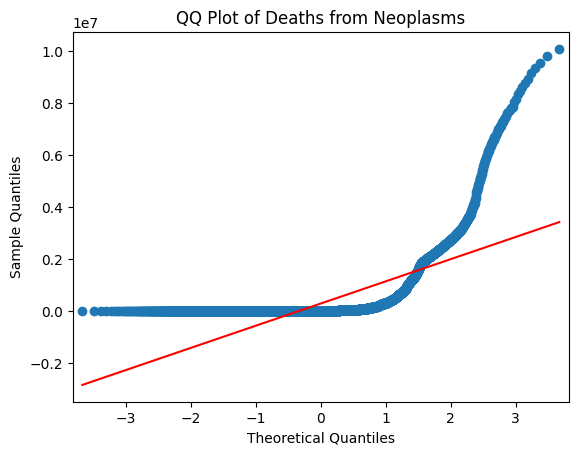

In [30]:
sm.qqplot(death_causes['deaths_neoplasms'], line='s')
plt.title("QQ Plot of Deaths from Neoplasms")
plt.show()

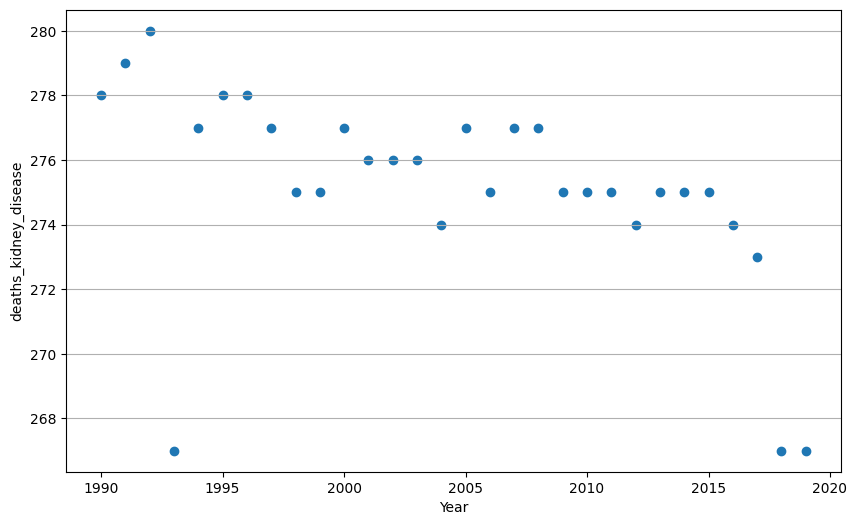

In [31]:
plt.figure(figsize=(10,6))
plt.scatter(death_causes['Year'].value_counts().index, death_causes['Year'].value_counts().values)
plt.xlabel('Year')
plt.ylabel('deaths_kidney_disease')
plt.title('')
plt.grid(axis='y')
plt.show()

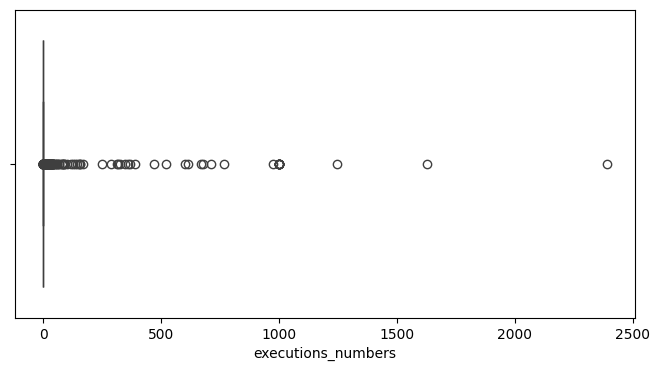

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.boxplot(x=death_causes['executions_numbers'])
plt.show()

In [34]:
death_causes.columns

Index(['country', 'Year', 'executions_numbers', 'deaths_meningitis',
       'deaths_neoplasms', 'deaths_thermal_injuries', 'deaths_malaria',
       'deaths_drowning', 'deaths_violence', 'deaths_hiv', 'deaths_drugs',
       'deaths_tuberculosis', 'deaths_road_injuries',
       'deaths_maternal_disorder', 'deaths_respiratory_infections',
       'deaths_neonatal_disorder', 'deaths_alcohol',
       'deaths_natural_disasters', 'deaths_diarrheal_disease',
       'deaths_heat_cold_exposure', 'deaths_nutritional_deficiencies',
       'deaths_self_harm', 'deaths_conflict_terrorism', 'deaths_diabetes',
       'deaths_poisonings', 'deaths_protein_energy_malnutrition',
       'deaths_conflict_terrorism', 'deaths_cardiovascular_disease',
       'deaths_kidney_disease', 'deaths_respiratory_disease',
       'deaths_liver_disease', 'deaths_digestive_disease',
       'deaths_acute_hepatitis', 'deaths_alzheimers_dementias',
       'deaths_parkinsons_disease'],
      dtype='object')

* We used this to see if there is any outliers but the visual is normal because execution is prohbitted in many countries